# 네트워크 침입 탐지(IDS) — JupyterLab + MLflow 파이프라인

기존 `code.ipynb`를 현재 개발 서버 구조에 맞게 개편한 버전입니다.

### 디렉터리 기준
- 원본: `datasets/<프로젝트>/raw/`
- Parquet 중간본: `datasets/<프로젝트>/interim/`
- 가공 데이터: `datasets/<프로젝트>/processed/`
- 노트북: `<프로젝트>/notebooks/`
- 결과: `<프로젝트>/outputs/`
- 실험 추적: MLflow (`http://mlflow:5000`)

### 실행 흐름
1. CSV / XLSX / Parquet 자동 탐색
2. 대용량 원본을 Parquet으로 1회 변환
3. DuckDB로 전체 구조·클래스 분포 확인
4. 분석용 샘플 로딩
5. IDS 파생변수 생성
6. Stratified Train/Validation
7. Logistic Regression / LightGBM 비교
8. MLflow에 지표·모델·리포트 기록
9. Champion 모델 선택
10. Test 예측 및 `submission.csv`

> 원본의 CNN/CNN-LSTM은 현재 기본 Docker 이미지에 TensorFlow가 없으므로 기본 실행 경로에서 제외했습니다.
> 먼저 CPU 기반 ML 파이프라인을 안정화한 뒤 Deep Learning 실험을 별도 노트북으로 추가하는 구성이 적합합니다.

In [1]:
from pathlib import Path
import csv
import os
import tempfile
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import mlflow
import mlflow.sklearn

from openpyxl import load_workbook
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --------------------------------
# 프로젝트/디렉터리 자동 감지
# --------------------------------
WORK_ROOT = Path("/home/jovyan/work")
cwd = Path.cwd()

# 1) 현재 노트북 위치에서 프로젝트명 후보 추출
if cwd.name == "notebooks":
    notebook_project = cwd.parent.name
elif cwd.parent.name == "notebooks":
    notebook_project = cwd.parent.parent.name
else:
    notebook_project = None

# 2) 데이터 루트 후보
DATA_BASES = [
    WORK_ROOT / "datasets",
    Path("/home/jovyan/data"),
]

SUPPORTED_RAW = {".csv", ".xlsx", ".parquet"}

def has_train_file(raw_dir: Path) -> bool:
    if not raw_dir.exists():
        return False
    for p in raw_dir.iterdir():
        if (
            p.is_file()
            and p.suffix.lower() in SUPPORTED_RAW
            and p.stem.lower().startswith("train")
        ):
            return True
    return False

# 3) notebook 프로젝트명과 같은 datasets/<project>/raw 를 먼저 탐색
detected = None

if notebook_project:
    for base in DATA_BASES:
        candidate = base / notebook_project
        if has_train_file(candidate / "raw"):
            detected = candidate
            break

# 4) 못 찾으면 datasets 하위 전체 프로젝트에서 train 파일 자동 검색
if detected is None:
    matches = []

    for base in DATA_BASES:
        if not base.exists():
            continue

        for raw_dir in base.glob("*/raw"):
            if has_train_file(raw_dir):
                matches.append(raw_dir.parent)

    if len(matches) == 1:
        detected = matches[0]
    elif len(matches) > 1:
        print("학습 데이터가 있는 프로젝트가 여러 개 발견되었습니다:")
        for m in matches:
            print(" -", m)
        raise RuntimeError(
            "프로젝트가 여러 개입니다. PROJECT_NAME을 명시적으로 지정해주세요."
        )

# 5) 실제 데이터가 하나도 없으면 notebook 프로젝트명 또는 기본값 사용
if detected is not None:
    DATA_ROOT = detected
    PROJECT_NAME = detected.name
else:
    PROJECT_NAME = notebook_project or "network-classification"
    DATA_ROOT = DATA_BASES[0] / PROJECT_NAME

PROJECT_DIR = WORK_ROOT / PROJECT_NAME

RAW_DIR = DATA_ROOT / "raw"
INTERIM_DIR = DATA_ROOT / "interim"
PROCESSED_DIR = DATA_ROOT / "processed"
EXTERNAL_DIR = DATA_ROOT / "external"
OUTPUT_DIR = PROJECT_DIR / "outputs"

# 데이터 폴더는 없는 경우 생성하되, 자동감지 결과를 먼저 출력
for p in [RAW_DIR, INTERIM_DIR, PROCESSED_DIR, EXTERNAL_DIR, OUTPUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("현재 Notebook 위치 :", cwd)
print("감지된 프로젝트명   :", PROJECT_NAME)
print("감지된 DATA_ROOT    :", DATA_ROOT)

# --------------------------------
# 분석 설정
# --------------------------------
ID_COL = "unique_id"
TARGET = "Label"
DROP_COLS = ["Timestamp"]
CAT_FEATURES = ["Dst Port", "Protocol"]

EDA_SAMPLE = 100_000
TRAIN_SAMPLE = 250_000
VALID_SIZE = 0.20

# random sample에서 시간 rolling을 계산하면 실제 간격이 왜곡될 수 있어 기본 False
USE_TEMPORAL_FEATURES = False

# --------------------------------
# MLflow
# --------------------------------
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://mlflow:5000")
EXPERIMENT_NAME = f"{PROJECT_NAME}-ids"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print("PROJECT_NAME :", PROJECT_NAME)
print("PROJECT_DIR  :", PROJECT_DIR)
print("DATA_ROOT    :", DATA_ROOT)
print("RAW_DIR      :", RAW_DIR)
print("OUTPUT_DIR   :", OUTPUT_DIR)
print("MLflow       :", MLFLOW_TRACKING_URI)
print("Experiment   :", EXPERIMENT_NAME)

현재 Notebook 위치 : /home/jovyan/work/network-classification/notebooks
감지된 프로젝트명   :  📁 network-classification
감지된 DATA_ROOT    : /home/jovyan/work/datasets/ 📁 network-classification
PROJECT_NAME :  📁 network-classification
PROJECT_DIR  : /home/jovyan/work/ 📁 network-classification
DATA_ROOT    : /home/jovyan/work/datasets/ 📁 network-classification
RAW_DIR      : /home/jovyan/work/datasets/ 📁 network-classification/raw
OUTPUT_DIR   : /home/jovyan/work/ 📁 network-classification/outputs
MLflow       : http://mlflow:5000
Experiment   :  📁 network-classification-ids


## 1. RAW 데이터 자동 탐색

`raw/` 폴더에서 `train_saved.*`, `test_saved.*` 또는 `train.*`, `test.*`를 찾습니다.
지원 형식은 `.csv`, `.xlsx`, `.parquet`입니다.

In [2]:
SUPPORTED = {".csv", ".xlsx", ".parquet"}

def find_raw_file(kind: str):
    priority = [
        f"{kind}_saved.parquet",
        f"{kind}_saved.csv",
        f"{kind}_saved.xlsx",
        f"{kind}.parquet",
        f"{kind}.csv",
        f"{kind}.xlsx",
    ]

    for name in priority:
        p = RAW_DIR / name
        if p.exists():
            return p

    candidates = [
        p for p in sorted(RAW_DIR.glob(f"{kind}*"))
        if p.is_file() and p.suffix.lower() in SUPPORTED
    ]
    return candidates[0] if candidates else None

TRAIN_RAW = find_raw_file("train")
TEST_RAW = find_raw_file("test")

print("TRAIN RAW:", TRAIN_RAW)
print("TEST  RAW:", TEST_RAW)

if TRAIN_RAW is None:
    print("\n현재 raw 폴더 내용:")
    if RAW_DIR.exists():
        for p in sorted(RAW_DIR.iterdir()):
            print(" -", p.name)
    raise FileNotFoundError(
        f"train 파일을 찾지 못했습니다.\n"
        f"현재 탐색 위치: {RAW_DIR}\n"
        f"지원 파일명 예: train_saved.csv / train_saved.xlsx / train_saved.parquet"
    )

TRAIN RAW: /home/jovyan/work/datasets/ 📁 network-classification/raw/train_saved.csv
TEST  RAW: /home/jovyan/work/datasets/ 📁 network-classification/raw/test_saved.csv


## 2. RAW → Parquet

대용량 데이터를 매번 Excel/CSV로 읽지 않도록 `interim/train.parquet`, `interim/test.parquet`으로 변환합니다.

- CSV: DuckDB로 직접 변환
- XLSX: `openpyxl` read-only 스트리밍 → 임시 CSV → Parquet
- Parquet: 원본을 그대로 사용

1GB급 Excel도 `pd.read_excel()`로 한 번에 메모리에 올리지 않습니다.

In [3]:
def sql_path(path: Path) -> str:
    return str(path).replace("'", "''")

def parquet_expr(path: Path) -> str:
    return f"read_parquet('{sql_path(path)}')"

def csv_to_parquet(csv_path: Path, parquet_path: Path):
    parquet_path.parent.mkdir(parents=True, exist_ok=True)
    src = sql_path(csv_path)
    dst = sql_path(parquet_path)

    con = duckdb.connect()
    con.execute(f"""
        COPY (
            SELECT *
            FROM read_csv_auto(
                '{src}',
                HEADER = TRUE,
                SAMPLE_SIZE = -1
            )
        )
        TO '{dst}'
        (FORMAT PARQUET, COMPRESSION ZSTD)
    """)
    con.close()

def xlsx_to_csv_stream(xlsx_path: Path, csv_path: Path):
    wb = load_workbook(xlsx_path, read_only=True, data_only=True)
    ws = wb[wb.sheetnames[0]]
    print("Excel sheet:", ws.title)

    rows = ws.iter_rows(values_only=True)
    header = next(rows)

    count = 0
    with open(csv_path, "w", newline="", encoding="utf-8-sig") as f:
        writer = csv.writer(f)
        writer.writerow(header)

        for count, row in enumerate(rows, start=1):
            writer.writerow(row)
            if count % 100_000 == 0:
                print(f"  {count:,} rows converted")

    wb.close()
    print(f"Excel streaming 완료: {count:,} rows")

def ensure_parquet(raw_path: Path | None, output_name: str):
    if raw_path is None:
        return None

    target = INTERIM_DIR / output_name

    if target.exists():
        print("[재사용]", target)
        return target

    suffix = raw_path.suffix.lower()

    if suffix == ".parquet":
        return raw_path

    if suffix == ".csv":
        print("[CSV → Parquet]", raw_path.name)
        csv_to_parquet(raw_path, target)
        return target

    if suffix == ".xlsx":
        print("[XLSX → Parquet]", raw_path.name)
        with tempfile.TemporaryDirectory(dir=str(INTERIM_DIR)) as tmpdir:
            tmp_csv = Path(tmpdir) / f"{raw_path.stem}.csv"
            xlsx_to_csv_stream(raw_path, tmp_csv)
            csv_to_parquet(tmp_csv, target)
        return target

    raise ValueError(f"지원하지 않는 형식: {suffix}")

TRAIN_PARQUET = ensure_parquet(TRAIN_RAW, "train.parquet")
TEST_PARQUET = ensure_parquet(TEST_RAW, "test.parquet")

print("TRAIN PARQUET:", TRAIN_PARQUET)
print("TEST  PARQUET:", TEST_PARQUET)

[재사용] /home/jovyan/work/datasets/ 📁 network-classification/interim/train.parquet
[재사용] /home/jovyan/work/datasets/ 📁 network-classification/interim/test.parquet
TRAIN PARQUET: /home/jovyan/work/datasets/ 📁 network-classification/interim/train.parquet
TEST  PARQUET: /home/jovyan/work/datasets/ 📁 network-classification/interim/test.parquet


## 3. 전체 데이터 구조 확인

DuckDB를 사용하므로 전체 데이터를 Pandas RAM에 올리지 않고 행 수, 스키마, 클래스 분포를 확인합니다.

In [4]:
con = duckdb.connect()

train_rows = con.execute(
    f"SELECT COUNT(*) FROM {parquet_expr(TRAIN_PARQUET)}"
).fetchone()[0]

train_schema = con.execute(
    f"DESCRIBE SELECT * FROM {parquet_expr(TRAIN_PARQUET)}"
).df()

print(f"Train rows: {train_rows:,}")
display(train_schema)

train_columns = train_schema["column_name"].tolist()

if TARGET not in train_columns:
    raise KeyError(f"학습 데이터에 '{TARGET}' 컬럼이 없습니다.")

class_counts = con.execute(f"""
    SELECT
        "{TARGET}" AS label,
        COUNT(*) AS count
    FROM {parquet_expr(TRAIN_PARQUET)}
    GROUP BY "{TARGET}"
    ORDER BY count DESC
""").df()

class_counts["ratio"] = class_counts["count"] / class_counts["count"].sum()
display(class_counts)

if TEST_PARQUET is not None:
    test_rows = con.execute(
        f"SELECT COUNT(*) FROM {parquet_expr(TEST_PARQUET)}"
    ).fetchone()[0]
    print(f"Test rows: {test_rows:,}")

con.close()

Train rows: 4,638,804


,column_name,column_type,null,key,default,extra
0,unique_id,VARCHAR,YES,None,None,None
1,Dst Port,VARCHAR,YES,None,None,None
2,Protocol,BIGINT,YES,None,None,None
3,Timestamp,TIMESTAMP,YES,None,None,None
4,Flow Duration,BIGINT,YES,None,None,None
5,Tot Fwd Pkts,BIGINT,YES,None,None,None
6,Tot Bwd Pkts,BIGINT,YES,None,None,None
7,TotLen Fwd Pkts,BIGINT,YES,None,None,None
8,TotLen Bwd Pkts,DOUBLE,YES,None,None,None
9,Flow Byts/s,DOUBLE,YES,None,None,None


,label,count,ratio
0,Benign,3191824,0.688070
1,DDOS,550194,0.118607
2,DoS,518077,0.111683
3,Brute Force,305045,0.065759
4,Infilteration,73664,0.015880


Test rows: 1,159,701


## 4. 분석용 샘플 로딩

기본값은 25만 행입니다. 원본이 더 커도 Jupyter 메모리를 과도하게 사용하지 않도록 DuckDB Reservoir Sampling을 사용합니다.

In [5]:
def load_train_sample(path: Path, n_rows: int | None):
    con = duckdb.connect()
    src = parquet_expr(path)
    total = con.execute(f"SELECT COUNT(*) FROM {src}").fetchone()[0]

    if n_rows is None or n_rows >= total:
        if n_rows is None:
            print("주의: 전체 train 데이터를 Pandas로 로드합니다.")
        df = con.execute(f"SELECT * FROM {src}").df()
        con.close()
        return df

    try:
        df = con.execute(f"""
            SELECT *
            FROM {src}
            USING SAMPLE reservoir({int(n_rows)} ROWS)
            REPEATABLE ({RANDOM_STATE})
        """).df()
    except Exception as e:
        print("Reservoir sampling 실패 → LIMIT fallback:", e)
        df = con.execute(
            f"SELECT * FROM {src} LIMIT {int(n_rows)}"
        ).df()

    con.close()
    return df

train_df = load_train_sample(TRAIN_PARQUET, TRAIN_SAMPLE)

print("Loaded train:", train_df.shape)
print(
    "Memory:",
    f"{train_df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB"
)
display(train_df.head(3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded train: (250000, 43)
Memory: 114.9 MB


,unique_id,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,2224562L,B,17,2018-02-14 11:41:48,317,1,1,41,169.0,662460.567823,6309.148265,317.000000,0.000000,317.0,317.0,41,169,83.666667,73.900834,5461.333333,0,0,0,0,0,0,0,0,1,125.5,1,41,1,169,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,6271717D,D,6,2018-02-23 10:51:47,2939799,9,9,1341,2754.0,1392.952375,6.122868,172929.352941,241127.649534,953082.0,39.0,0,1173,215.526316,373.545382,139536.152047,0,0,0,1,0,0,0,0,1,227.5,9,1341,9,2754,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,9085515Z,A,6,2018-02-21 02:24:10,737,2,0,0,0.0,0.000000,2713.704206,737.000000,0.000000,737.0,737.0,0,0,0.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,0.0,2,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DDOS


## 5. IDS 파생변수

원본 노트북의 TCP 핸드셰이크 가설은 유지합니다.

시간 기반 `dt_prev`, rolling 통계도 함수에 포함되어 있지만,
랜덤 샘플에서 계산하면 원래 이벤트 간격이 왜곡될 수 있어 기본값은 `USE_TEMPORAL_FEATURES=False`입니다.

In [6]:
def add_features(df: pd.DataFrame, use_temporal: bool = False):
    df = df.copy()

    flag_cols = [
        "SYN Flag Cnt", "ACK Flag Cnt", "RST Flag Cnt",
        "FIN Flag Cnt", "URG Flag Cnt", "PSH Flag Cnt"
    ]

    if all(c in df.columns for c in flag_cols):
        syn = pd.to_numeric(df["SYN Flag Cnt"], errors="coerce").fillna(0).astype(float)
        ack = pd.to_numeric(df["ACK Flag Cnt"], errors="coerce").fillna(0).astype(float)
        rst = pd.to_numeric(df["RST Flag Cnt"], errors="coerce").fillna(0).astype(float)
        fin = pd.to_numeric(df["FIN Flag Cnt"], errors="coerce").fillna(0).astype(float)
        urg = pd.to_numeric(df["URG Flag Cnt"], errors="coerce").fillna(0).astype(float)
        psh = pd.to_numeric(df["PSH Flag Cnt"], errors="coerce").fillna(0).astype(float)

        total_flags = syn + ack + rst + fin + urg + psh + 1.0

        df["SYN_ACK_ratio"] = (syn + 1) / (ack + 1)
        df["RST_ACK_ratio"] = (rst + 1) / (ack + 1)
        df["SYN_RST_over_ACK_FIN"] = (syn + rst + 1) / (ack + fin + 1)
        df["ACK_SYN_ratio"] = (ack + 1) / (syn + 1)
        df["URG_ACK_ratio"] = (urg + 1) / (ack + 1)
        df["SYN_share"] = (syn + 1) / total_flags
        df["RST_share"] = (rst + 1) / total_flags

    if use_temporal:
        needed = ["Timestamp", "Flow Pkts/s", "Tot Fwd Pkts"]

        if all(c in df.columns for c in needed):
            work = df.copy()
            work["_ts"] = pd.to_datetime(work["Timestamp"], errors="coerce")
            work = work.sort_values("_ts", kind="stable")

            work["dt_prev"] = (
                work["_ts"].diff().dt.total_seconds().fillna(0.0)
            )

            W = 1000
            flow_rate = (
                pd.to_numeric(work["Flow Pkts/s"], errors="coerce")
                .replace([np.inf, -np.inf], np.nan)
                .fillna(0.0)
            )
            fwd_pkts = (
                pd.to_numeric(work["Tot Fwd Pkts"], errors="coerce")
                .replace([np.inf, -np.inf], np.nan)
                .fillna(0.0)
            )

            work["roll_dt_mean"] = work["dt_prev"].rolling(W, min_periods=1).mean()
            work["roll_pkt_std"] = flow_rate.rolling(W, min_periods=1).std().fillna(0)
            work["roll_fwd_std"] = fwd_pkts.rolling(W, min_periods=1).std().fillna(0)

            work = work.sort_index()

            for c in ["dt_prev", "roll_dt_mean", "roll_pkt_std", "roll_fwd_std"]:
                df[c] = work[c]

    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

    return df

train_df = add_features(train_df, USE_TEMPORAL_FEATURES)
print("Feature engineering:", train_df.shape)

Feature engineering: (250000, 50)


## 6. EDA

,count,ratio
Label,,
Benign,171743,0.686972
DDOS,29839,0.119356
DoS,27765,0.111060
Brute Force,16588,0.066352
Infilteration,4065,0.016260


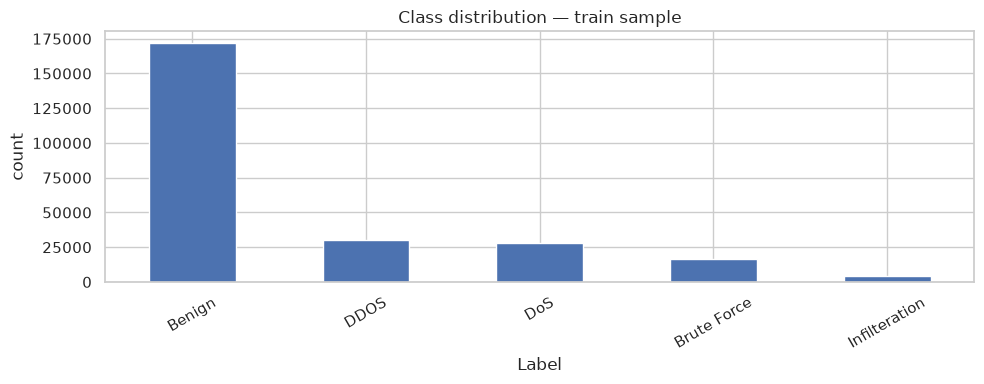

결측치 상위 20개


,missing
Flow Pkts/s,38
Flow Byts/s,38


In [7]:
sample_counts = train_df[TARGET].value_counts()

display(pd.DataFrame({
    "count": sample_counts,
    "ratio": sample_counts / sample_counts.sum()
}))

fig, ax = plt.subplots(figsize=(10, 4))
sample_counts.plot(kind="bar", ax=ax)
ax.set_title("Class distribution — train sample")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

missing = train_df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("결측치 상위 20개")
display(missing.head(20).to_frame("missing"))

## 7. Train / Validation + 전처리

- `Timestamp`, `unique_id`는 모델 입력에서 제외
- 수치형: 결측 → 0 → StandardScaler
- 범주형: 결측 대체 → OneHotEncoder
- Stratified 80/20 split

In [8]:
drop_for_X = [TARGET] + [c for c in DROP_COLS if c in train_df.columns]

X = train_df.drop(columns=drop_for_X, errors="ignore")
y = train_df[TARGET].astype(str)

if ID_COL in X.columns:
    X = X.drop(columns=[ID_COL])

cat_features = [c for c in CAT_FEATURES if c in X.columns]
num_features = [c for c in X.columns if c not in cat_features]

for c in cat_features:
    X[c] = X[c].astype("string")

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=VALID_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_features),
    ("cat", categorical_pipe, cat_features),
])

classes = sorted(y_train.unique().tolist())
attack_classes = [c for c in classes if c != "Benign"]

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)
print("Classes:", classes)
print("Attack classes:", attack_classes)
print("Numeric:", len(num_features))
print("Categorical:", cat_features)

Train: (200000, 47)
Valid: (50000, 47)
Classes: ['Benign', 'Brute Force', 'DDOS', 'DoS', 'Infilteration']
Attack classes: ['Brute Force', 'DDOS', 'DoS', 'Infilteration']
Numeric: 45
Categorical: ['Dst Port', 'Protocol']


## 8. 평가 + MLflow 기록 함수

선택 기준은 원본 노트북과 동일하게 **Benign 제외 공격 클래스 Weighted F1**입니다.
추가로 Macro F1, Accuracy, Infiltration Recall/F1을 기록합니다.

In [9]:
def evaluate_predictions(y_true, y_pred):
    metrics = {
        "weighted_f1_attacks": float(
            f1_score(
                y_true, y_pred,
                labels=attack_classes,
                average="weighted",
                zero_division=0,
            )
        ),
        "macro_f1_attacks": float(
            f1_score(
                y_true, y_pred,
                labels=attack_classes,
                average="macro",
                zero_division=0,
            )
        ),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }

    if "Infiltration" in classes:
        p, r, f, _ = precision_recall_fscore_support(
            y_true, y_pred,
            labels=["Infiltration"],
            average=None,
            zero_division=0,
        )
        metrics["infiltration_precision"] = float(p[0])
        metrics["infiltration_recall"] = float(r[0])
        metrics["infiltration_f1"] = float(f[0])

    return metrics

def save_eval_artifacts(y_true, y_pred, model_name):
    safe = model_name.lower().replace(" ", "_").replace("/", "_")

    report = classification_report(
        y_true, y_pred,
        labels=classes,
        output_dict=True,
        zero_division=0,
    )
    report_path = OUTPUT_DIR / f"{safe}_classification_report.csv"
    pd.DataFrame(report).T.to_csv(report_path, encoding="utf-8-sig")

    cm = confusion_matrix(y_true, y_pred, labels=classes)

    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix — {model_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()

    cm_path = OUTPUT_DIR / f"{safe}_confusion_matrix.png"
    fig.savefig(cm_path, dpi=140, bbox_inches="tight")
    plt.close(fig)

    return report_path, cm_path

def run_experiment(model_name, estimator, extra_params=None):
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", estimator),
    ])

    start = time.time()

    with mlflow.start_run(run_name=model_name) as run:
        mlflow.set_tags({
            "project": PROJECT_NAME,
            "task": "IDS multiclass classification",
            "temporal_features": str(USE_TEMPORAL_FEATURES),
        })

        mlflow.log_params({
            "model_name": model_name,
            "random_state": RANDOM_STATE,
            "train_sample": "full" if TRAIN_SAMPLE is None else TRAIN_SAMPLE,
            "valid_size": VALID_SIZE,
            "n_numeric_features": len(num_features),
            "n_categorical_features": len(cat_features),
        })

        if extra_params:
            mlflow.log_params(extra_params)

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_valid)

        metrics = evaluate_predictions(y_valid, pred)
        metrics["train_seconds"] = time.time() - start
        mlflow.log_metrics(metrics)

        report_path, cm_path = save_eval_artifacts(
            y_valid, pred, model_name
        )

        mlflow.log_artifact(str(report_path), artifact_path="evaluation")
        mlflow.log_artifact(str(cm_path), artifact_path="evaluation")

        # 전처리 + 모델을 통째로 저장
        mlflow.sklearn.log_model(
            pipe,
            name="model",
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
        )

        run_id = run.info.run_id

    print(f"[{model_name}]")
    for k, v in metrics.items():
        print(f"{k:26s}: {v:.5f}")

    print("run_id:", run_id)

    return {
        "name": model_name,
        "pipeline": pipe,
        "metrics": metrics,
        "run_id": run_id,
    }

## 9. Baseline — Logistic Regression

In [10]:
lr_result = run_experiment(
    "LogisticRegression",
    LogisticRegression(
        max_iter=300,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    extra_params={
        "class_weight": "balanced",
        "max_iter": 300,
    },
)

2026/08/15 13:40:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LogisticRegression at: http://mlflow:5000/#/experiments/2/runs/403e7021c12845f9acaf4602d8bf5a6d
🧪 View experiment at: http://mlflow:5000/#/experiments/2
[LogisticRegression]
weighted_f1_attacks       : 0.56047
macro_f1_attacks          : 0.47971
accuracy                  : 0.47192
train_seconds             : 15.29488
run_id: 403e7021c12845f9acaf4602d8bf5a6d


## 10. Main Model — LightGBM

In [11]:
lgbm_params = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": -1,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
}

lgbm_result = run_experiment(
    "LightGBM",
    LGBMClassifier(
        **lgbm_params,
        objective="multiclass",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    ),
    extra_params={
        **lgbm_params,
        "class_weight": "balanced",
    },
)

2026/08/15 13:41:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LightGBM at: http://mlflow:5000/#/experiments/2/runs/463873a720c041dfb5ecc7c49183d6db
🧪 View experiment at: http://mlflow:5000/#/experiments/2
[LightGBM]
weighted_f1_attacks       : 0.74670
macro_f1_attacks          : 0.65155
accuracy                  : 0.86796
train_seconds             : 23.76236
run_id: 463873a720c041dfb5ecc7c49183d6db


## 11. 모델 비교 / Champion 선택

In [12]:
results = [lr_result, lgbm_result]

summary = pd.DataFrame([
    {
        "model": r["name"],
        **r["metrics"],
        "run_id": r["run_id"],
    }
    for r in results
]).sort_values("weighted_f1_attacks", ascending=False)

display(summary)

best_result = max(
    results,
    key=lambda r: r["metrics"]["weighted_f1_attacks"]
)

best_name = best_result["name"]
best_pipeline = best_result["pipeline"]
best_run_id = best_result["run_id"]

print(
    f"Champion: {best_name} | "
    f"Weighted-F1(attacks)="
    f"{best_result['metrics']['weighted_f1_attacks']:.5f}"
)

,model,weighted_f1_attacks,macro_f1_attacks,accuracy,train_seconds,run_id
1,LightGBM,0.746698,0.651551,0.86796,23.762358,463873a720c041dfb5ecc7c49183d6db
0,LogisticRegression,0.560466,0.479707,0.47192,15.294885,403e7021c12845f9acaf4602d8bf5a6d


Champion: LightGBM | Weighted-F1(attacks)=0.74670


## 12. 선택 — MLflow Model Registry 등록

Validation 결과를 확인한 뒤 `REGISTER_BEST_MODEL=True`로 변경하면 Champion 모델을 Registry에 등록합니다.

In [13]:
REGISTER_BEST_MODEL = False

if REGISTER_BEST_MODEL:
    registered_name = f"{PROJECT_NAME}-classifier"

    mv = mlflow.register_model(
        model_uri=f"runs:/{best_run_id}/model",
        name=registered_name,
    )

    print("Registered:", registered_name)
    print("Version:", mv.version)
else:
    print("Model Registry 등록 생략")

Model Registry 등록 생략


## 13. Test 전체 예측 / Submission

`outputs/submission.csv`로 저장합니다.

In [14]:
def load_full_parquet(path: Path):
    con = duckdb.connect()
    df = con.execute(
        f"SELECT * FROM {parquet_expr(path)}"
    ).df()
    con.close()
    return df

if TEST_PARQUET is None:
    print("Test 데이터가 없어 제출 생략")
else:
    test_df = load_full_parquet(TEST_PARQUET)

    print("Loaded test:", test_df.shape)
    print(
        "Memory:",
        f"{test_df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB"
    )

    test_df = add_features(
        test_df,
        use_temporal=USE_TEMPORAL_FEATURES
    )

    if ID_COL not in test_df.columns:
        raise KeyError(f"Test 데이터에 '{ID_COL}' 컬럼이 없습니다.")

    test_ids = test_df[ID_COL].copy()

    X_test = test_df.drop(
        columns=[
            ID_COL,
            TARGET,
            *[c for c in DROP_COLS if c in test_df.columns],
        ],
        errors="ignore",
    )

    for c in cat_features:
        if c in X_test.columns:
            X_test[c] = X_test[c].astype("string")

    test_pred = best_pipeline.predict(X_test)

    submission = pd.DataFrame({
        ID_COL: test_ids,
        TARGET: test_pred,
    }).set_index(ID_COL)

    submission_path = OUTPUT_DIR / "submission.csv"
    submission.to_csv(submission_path, encoding="utf-8-sig")

    print("Saved:", submission_path)
    print("Shape:", submission.shape)
    display(submission.head())
    display(submission[TARGET].value_counts())

Loaded test: (1159701, 43)
Memory: 498.8 MB
Saved: /home/jovyan/work/ 📁 network-classification/outputs/submission.csv
Shape: (1159701, 1)


,Label
unique_id,
8093282X,DDOS
5372892S,Benign
3627842Z,Brute Force
7554377I,Benign
6650145Z,Brute Force


Label
Benign           731719
DDOS             169656
DoS               90974
Brute Force       90429
Infilteration     76923
Name: count, dtype: int64

## 14. Submission 검증

In [15]:
submission_path = OUTPUT_DIR / "submission.csv"

if submission_path.exists():
    chk = pd.read_csv(
        submission_path,
        index_col=ID_COL,
        encoding="utf-8-sig",
    )

    print("Shape:", chk.shape)
    print("Label missing:", int(chk[TARGET].isna().sum()))
    print("Duplicate ID:", int(chk.index.duplicated().sum()))
    display(chk.head())
else:
    print("submission.csv 없음")

Shape: (1159701, 1)
Label missing: 0
Duplicate ID: 0


,Label
unique_id,
8093282X,DDOS
5372892S,Benign
3627842Z,Brute Force
7554377I,Benign
6650145Z,Brute Force


# 다음 구조로 확장

파이프라인이 정상 동작하면 Notebook 안의 코드를 다음 파일들로 분리하면 됩니다.

```text
network-classification/
├── notebooks/
│   └── code_mlflow_pipeline.ipynb
├── src/
│   ├── ingest.py
│   ├── features.py
│   ├── train.py
│   ├── evaluate.py
│   └── predict.py
├── configs/
│   └── config.yaml
└── outputs/
```

특히 `Timestamp` 기반 시계열 파생변수는 random sample에서 만들지 않고,
전체 Parquet을 시간 순서대로 처리하는 `src/features.py` 단계로 옮기는 것이 다음 개선 포인트입니다.

In [21]:
import duckdb
import pandas as pd

con = duckdb.connect()

label_full = con.execute(f"""
    SELECT
        "Label",
        COUNT(*) AS count
    FROM {parquet_expr(TRAIN_PARQUET)}
    GROUP BY "Label"
    ORDER BY count DESC
""").df()

con.close()

print("전체 고유 Label 개수:", len(label_full))

display(label_full)

전체 고유 Label 개수: 5


,Label,count
0,Benign,3191824
1,DDOS,550194
2,DoS,518077
3,Brute Force,305045
4,Infilteration,73664


In [22]:
from difflib import SequenceMatcher

labels = label_full.copy()

labels["label_str"] = (
    labels["Label"]
    .astype(str)
)

labels["normalized"] = (
    labels["label_str"]
    .str.strip()
    .str.lower()
)

target = "infiltration"

labels["similarity"] = labels["normalized"].apply(
    lambda x: SequenceMatcher(
        None,
        x,
        target
    ).ratio()
)

suspect = labels[
    (labels["normalized"].str.contains(
        "filtr|infil|filtrat",
        regex=True,
        na=False
    ))
    |
    (labels["similarity"] >= 0.60)
].sort_values(
    ["similarity", "count"],
    ascending=[False, False]
)

display(
    suspect[
        [
            "Label",
            "count",
            "normalized",
            "similarity"
        ]
    ]
)

,Label,count,normalized,similarity
4,Infilteration,73664,infilteration,0.96


In [23]:
for value in label_full["Label"]:
    print(repr(value))

'Benign'
'DDOS'
'DoS'
'Brute Force'
'Infilteration'


In [25]:
label_check = label_full.copy()

label_check["normalized"] = (
    label_check["Label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

display(
    label_check.groupby("normalized")["count"]
    .sum()
    .sort_values(ascending=False)
    .to_frame()
)

,count
normalized,
benign,3191824
ddos,550194
dos,518077
brute force,305045
infilteration,73664


In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

best_pred = best_pipeline.predict(X_valid)

report = classification_report(
    y_valid,
    best_pred,
    labels=classes,
    output_dict=True,
    zero_division=0
)

display(
    pd.DataFrame(report).T[
        ["precision", "recall", "f1-score", "support"]
    ].round(4)
)

cm = confusion_matrix(
    y_valid,
    best_pred,
    labels=classes
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual_{x}" for x in classes],
    columns=[f"Pred_{x}" for x in classes]
)

display(cm_df)

,precision,recall,f1-score,support
Benign,0.9885,0.9061,0.9455,34349.000
Brute Force,0.8487,0.9925,0.9150,3317.000
DDOS,0.7328,0.9125,0.8128,5968.000
DoS,0.7935,0.5521,0.6512,5553.000
Infilteration,0.1413,0.5806,0.2273,813.000
accuracy,0.8680,0.8680,0.8680,0.868
macro avg,0.7009,0.7887,0.7103,50000.000
weighted avg,0.9133,0.8680,0.8833,50000.000


,Pred_Benign,Pred_Brute Force,Pred_DDOS,Pred_DoS,Pred_Infilteration
Actual_Benign,31122,0,124,249,2854
Actual_Brute Force,0,3292,0,25,0
Actual_DDOS,0,0,5446,521,1
Actual_DoS,25,587,1861,3066,14
Actual_Infilteration,337,0,1,3,472


In [30]:
analysis_valid = X_valid.copy()

analysis_valid["actual"] = y_valid.values
analysis_valid["pred"] = best_pred

# 1. 실제 Infiltration을 제대로 잡은 데이터
inf_tp = analysis_valid[
    (analysis_valid["actual"] == "Infiltration") &
    (analysis_valid["pred"] == "Infiltration")
]

# 2. 실제 Infiltration인데 Benign으로 놓친 데이터
inf_fn = analysis_valid[
    (analysis_valid["actual"] == "Infiltration") &
    (analysis_valid["pred"] == "Benign")
]

# 3. 실제 Benign인데 Infiltration으로 오탐한 데이터
inf_fp = analysis_valid[
    (analysis_valid["actual"] == "Benign") &
    (analysis_valid["pred"] == "Infiltration")
]

# 4. 정상적으로 Benign으로 분류한 데이터
benign_tn = analysis_valid[
    (analysis_valid["actual"] == "Benign") &
    (analysis_valid["pred"] == "Benign")
]

print("Infiltration TP :", len(inf_tp))
print("Infiltration FN :", len(inf_fn))
print("Benign → Inf FP :", len(inf_fp))
print("Benign TN       :", len(benign_tn))

Infiltration TP : 0
Infiltration FN : 0
Benign → Inf FP : 0
Benign TN       : 31122


In [31]:
numeric_features = X_valid.select_dtypes(
    include="number"
).columns

compare = pd.DataFrame({
    "Inf_TP_median":
        inf_tp[numeric_features].median(),

    "Inf_FN_median":
        inf_fn[numeric_features].median(),

    "Benign_FP_median":
        inf_fp[numeric_features].median(),

    "Benign_TN_median":
        benign_tn[numeric_features].median(),
})

compare["TP_vs_FP_diff"] = (
    compare["Inf_TP_median"] -
    compare["Benign_FP_median"]
).abs()

display(
    compare
    .sort_values(
        "TP_vs_FP_diff",
        ascending=False
    )
    .head(30)
)

,Inf_TP_median,Inf_FN_median,Benign_FP_median,Benign_TN_median,TP_vs_FP_diff
Flow Duration,NaN,NaN,NaN,117671.000000,NaN
Tot Fwd Pkts,NaN,NaN,NaN,3.000000,NaN
Tot Bwd Pkts,NaN,NaN,NaN,2.000000,NaN
TotLen Fwd Pkts,NaN,NaN,NaN,80.000000,NaN
TotLen Bwd Pkts,NaN,NaN,NaN,211.000000,NaN
Flow Byts/s,NaN,NaN,NaN,1575.470383,NaN
Flow Pkts/s,NaN,NaN,NaN,40.272240,NaN
Flow IAT Mean,NaN,NaN,NaN,37340.500000,NaN
Flow IAT Std,NaN,NaN,NaN,15820.859159,NaN
Flow IAT Max,NaN,NaN,NaN,81162.000000,NaN


In [33]:
preprocessor = best_pipeline.named_steps[
    "preprocess"
]

lgbm = best_pipeline.named_steps[
    "model"
]

feature_names = (
    preprocessor
    .get_feature_names_out()
)

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": lgbm.feature_importances_
})

display(
    importance
    .sort_values(
        "importance",
        ascending=False
    )
    .head(30)
)

,feature,importance
10,num__Flow IAT Min,34606
6,num__Flow Pkts/s,19283
0,num__Flow Duration,18414
7,num__Flow IAT Mean,14853
9,num__Flow IAT Max,14670
5,num__Flow Byts/s,5278
14,num__Pkt Len Std,5062
3,num__TotLen Fwd Pkts,3807
8,num__Flow IAT Std,3489
13,num__Pkt Len Mean,3313


In [34]:
model = best_pipeline.named_steps["model"]

feature_names = (
    best_pipeline
    .named_steps["preprocess"]
    .get_feature_names_out()
)

importance_compare = pd.DataFrame({
    "feature": feature_names,

    "split": model.booster_.feature_importance(
        importance_type="split"
    ),

    "gain": model.booster_.feature_importance(
        importance_type="gain"
    )
})

importance_compare["gain_ratio"] = (
    importance_compare["gain"] /
    importance_compare["gain"].sum()
)

importance_compare = (
    importance_compare
    .sort_values(
        "gain",
        ascending=False
    )
)

display(
    importance_compare.head(30)
)

,feature,split,gain,gain_ratio
45,cat__Dst Port_A,1759,762592.980119,0.138949
6,num__Flow Pkts/s,19283,575154.498367,0.104797
51,cat__Dst Port_G,583,435521.752225,0.079355
10,num__Flow IAT Min,34606,368660.489791,0.067172
0,num__Flow Duration,18414,363389.563738,0.066212
9,num__Flow IAT Max,14670,348005.758238,0.063409
12,num__Pkt Len Max,2018,337122.234373,0.061426
44,num__RST_share,416,324993.261022,0.059216
14,num__Pkt Len Std,5062,250131.540717,0.045576
5,num__Flow Byts/s,5278,190710.976580,0.034749


In [35]:
inf_benign = train_df[
    train_df[TARGET].isin([
        "Benign",
        "Infiltration"
    ])
].copy()

print(
    inf_benign[TARGET]
    .value_counts()
)

Label
Benign    171743
Name: count, dtype: int64


In [36]:
check_features = [
    "Flow IAT Min",
    "Flow Pkts/s",
    "Flow Duration",
    "Flow IAT Mean",
    "Flow IAT Max",
    "Flow Byts/s",
    "Pkt Len Std",
    "TotLen Fwd Pkts",
    "Flow IAT Std",
    "Pkt Len Mean",
    "TotLen Bwd Pkts",
    "Pkt Size Avg",
    "Tot Fwd Pkts",
    "Pkt Len Max",
    "Tot Bwd Pkts",
    "URG_ACK_ratio",
    "RST_share",
]

check_features = [
    c for c in check_features
    if c in inf_benign.columns
]

comparison = (
    inf_benign
    .groupby(TARGET)[check_features]
    .agg(["mean", "median", "std"])
    .T
)

display(comparison)

Label                         Benign
Flow IAT Min    mean    1.602891e+06
                median  7.500000e+01
                std     9.161986e+06
Flow Pkts/s     mean    4.730527e+03
                median  5.307011e+01
                std     6.710168e+04
Flow Duration   mean    1.373459e+07
                median  8.042000e+04
                std     3.245368e+07
Flow IAT Mean   mean    2.137672e+06
                median  2.817467e+04
                std     9.254725e+06
Flow IAT Max    mean    5.767215e+06
                median  5.340100e+04
                std     1.535086e+07
Flow Byts/s     mean    1.473905e+05
                median  1.628012e+03
                std     1.997704e+06
Pkt Len Std     mean    1.446327e+02
                median  5.715768e+01
                std     1.716748e+02
TotLen Fwd Pkts mean    4.709373e+02
                median  7.700000e+01
                std     1.070555e+03
Flow IAT Std    mean    1.238100e+06
                median  1.127021e+04
                std     3.850393e+06
Pkt Len Mean    mean    1.004185e+02
                median  6.540000e+01
                std     1.211114e+02
TotLen Bwd Pkts mean    8.429309e+03
                median  1.820000e+02
                std     2.752462e+05
Pkt Size Avg    mean    1.152395e+02
                median  8.900000e+01
                std     1.223768e+02
Tot Fwd Pkts    mean    7.097774e+00
                median  3.000000e+00
                std     6.508543e+01
Pkt Len Max     mean    4.733735e+02
                median  1.430000e+02
                std     5.447910e+02
Tot Bwd Pkts    mean    9.787403e+00
                median  2.000000e+00
                std     1.898092e+02
URG_ACK_ratio   mean    9.225354e-01
                median  1.000000e+00
                std     1.810880e-01
RST_share       mean    7.041903e-01
                median  6.666667e-01
                std     2.380843e-01

In [37]:
features = [
    "Flow IAT Min",
    "Flow Pkts/s",
    "Flow Duration",
    "Flow IAT Mean",
    "Flow IAT Max",
    "Flow Byts/s",
    "Pkt Len Std",
    "TotLen Fwd Pkts",
    "Flow IAT Std",
    "Pkt Len Mean",
    "TotLen Bwd Pkts",
    "Pkt Size Avg",
    "Tot Fwd Pkts",
    "Pkt Len Max",
    "Tot Bwd Pkts",
    "URG_ACK_ratio",
    "RST_share",
]

features = [
    c for c in features
    if c in inf_benign.columns
]

comparison = (
    inf_benign
    .groupby(TARGET)[features]
    .median()
    .T
)

comparison["Inf_vs_Benign_ratio"] = (
    (comparison["Infiltration"] + 1)
    /
    (comparison["Benign"] + 1)
)

comparison["abs_log_ratio"] = (
    np.abs(
        np.log1p(comparison["Infiltration"])
        -
        np.log1p(comparison["Benign"])
    )
)

display(
    comparison
    .sort_values(
        "abs_log_ratio",
        ascending=False
    )
)

KeyError: 'Infiltration'

In [38]:
pwd

'/home/jovyan/work/network-classification/notebooks'